In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 10})

In [3]:
from pathlib import Path

import numpy as np

DATA_DIR = Path(".")
N_CLASSES = 10

# Data Load
missing = [f"{s}_{p}.csv" for s in ("train", "test") for p in ("in", "out") if not (DATA_DIR / f"{s}_{p}.csv").exists()]
assert not missing, f"Missing {missing}: put the data files in the same folder as this notebook."


def load_split(split):
    X = np.loadtxt(DATA_DIR / f"{split}_in.csv", delimiter=",")
    y = np.loadtxt(DATA_DIR / f"{split}_out.csv", delimiter=",").astype(int)
    return X, y


X_train, y_train = load_split("train")
X_test, y_test = load_split("test")


# Perceptron Core
def add_bias(X):
    return np.hstack([X, np.ones((len(X), 1))])


def targets(y):
    T = -np.ones((len(y), N_CLASSES))
    T[np.arange(len(y)), y] = 1
    return T


def predict(W, X):
    return (add_bias(X) @ W).argmax(axis=1)


def accuracy(W, X, y):
    return (predict(W, X) == y).mean()


def perceptron_loss(W, X, y, rule="ovr"):
    A = add_bias(X) @ W
    if rule == "ovr":
        return np.maximum(0, -targets(y) * A).sum(axis=1).mean()
    return (A.max(axis=1) - A[np.arange(len(y)), y]).mean()


def update_direction(A, y, rule="ovr"):
    if rule == "ovr":
        T = targets(y)
        return T * (T * A <= 0)
    pred = A.argmax(axis=1)
    wrong = (pred != y).astype(float)
    M = np.zeros_like(A)
    M[np.arange(len(y)), y] += wrong
    M[np.arange(len(y)), pred] -= wrong
    return M


def train_perceptron(X, y, lr=1.0, init_std=0.0, rule="ovr", batch_size=32, max_epochs=200, seed=42,
                     X_eval=None, y_eval=None):
    rng = np.random.default_rng(seed)
    Xb = add_bias(X)
    W = init_std * rng.standard_normal((Xb.shape[1], N_CLASSES))
    hist = {"train_acc": [], "train_loss": [], "test_acc": [], "test_loss": []}

    def record():
        hist["train_acc"].append(accuracy(W, X, y))
        hist["train_loss"].append(perceptron_loss(W, X, y, rule))
        if X_eval is not None:
            hist["test_acc"].append(accuracy(W, X_eval, y_eval))
            hist["test_loss"].append(perceptron_loss(W, X_eval, y_eval, rule))

    record()
    converged_at = None
    for epoch in range(1, max_epochs + 1):
        order = rng.permutation(len(X))
        n_mistakes = 0
        for start in range(0, len(X), batch_size):
            b = order[start:start + batch_size]
            M = update_direction(Xb[b] @ W, y[b], rule)
            W += lr * Xb[b].T @ M / len(b)
            n_mistakes += (M != 0).any(axis=1).sum()
        record()
        if n_mistakes == 0:
            converged_at = epoch - 1
            break
    for k, v in hist.items():
        hist[k] = np.array(v + v[-1:] * (max_epochs + 1 - len(v)))
    return W, hist, converged_at


DEFAULT = dict(lr=1.0, init_std=0.01, rule="ovr", batch_size=32, max_epochs=200)


DEFAULT settings ($\sigma = 0.01$, $\eta = 1$, one-vs-rest, batch size 32), 10 seeds. The seed changes both the initial weights and the shuffling order.

In [4]:
# Seed Runs
N_SEEDS = 10
runs = [train_perceptron(X_train, y_train, **DEFAULT, seed=SEED + s, X_eval=X_test, y_eval=y_test) for s in range(N_SEEDS)]
H = {k: np.stack([h[k] for _, h, _ in runs]) for k in runs[0][1]}
conv = np.array([c for _, _, c in runs], dtype=float)

print(f"train {X_train.shape}, test {X_test.shape}, class counts {np.bincount(y_train)}")
print(f"epochs to 100% train accuracy: {conv.mean():.0f} ± {conv.std():.0f} (all converged: {not np.isnan(conv).any()})")
print(f"final train accuracy {100 * H['train_acc'][:, -1].mean():.1f}%, "
      f"final test accuracy {100 * H['test_acc'][:, -1].mean():.1f} ± {100 * H['test_acc'][:, -1].std():.1f}%")
best = H["test_acc"].max(1)
print(f"best test accuracy during training {100 * best.mean():.1f}% (epoch {H['test_acc'].argmax(1).mean():.0f} on average)")

train (1707, 256), test (1000, 256), class counts [319 252 202 131 122  88 151 166 144 132]
epochs to 100% train accuracy: 78 ± 9 (all converged: True)
final train accuracy 100.0%, final test accuracy 87.7 ± 0.5%
best test accuracy during training 88.9% (epoch 27 on average)


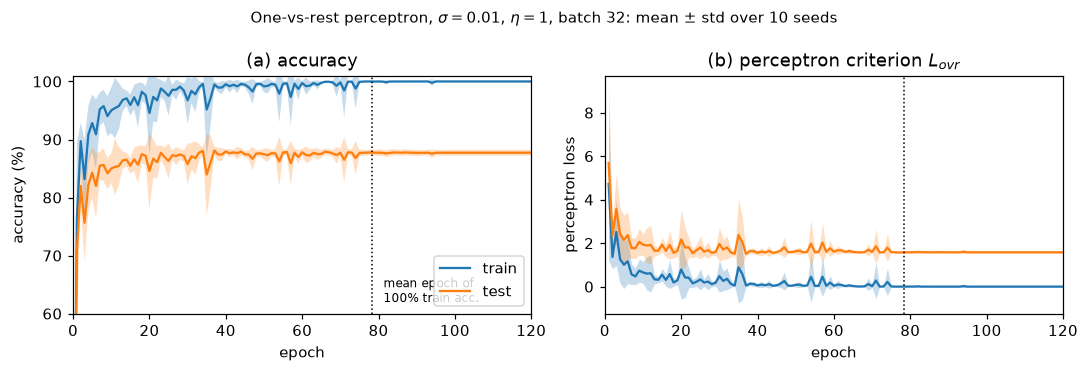

In [5]:
# Figure 2.1
ep = np.arange(DEFAULT["max_epochs"] + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, metric, scale in [(axes[0], "acc", 100), (axes[1], "loss", 1)]:
    for split, c in [("train", "C0"), ("test", "C1")]:
        v = scale * H[f"{split}_{metric}"]
        start = 0 if metric == "acc" else 1
        m, s = v.mean(0)[start:], v.std(0)[start:]
        ax.plot(ep[start:], m, color=c, label=split)
        ax.fill_between(ep[start:], m - s, m + s, color=c, alpha=0.25, lw=0)
    ax.axvline(conv.mean(), color="k", ls=":", lw=1)
    ax.set_xlabel("epoch")
axes[0].set(ylabel="accuracy (%)", ylim=(60, 101), xlim=(0, 120), title="(a) accuracy")
axes[1].set(ylabel="perceptron loss", xlim=(0, 120), title="(b) perceptron criterion $L_{ovr}$")
axes[0].text(conv.mean() + 3, 62, "mean epoch of\n100% train acc.", fontsize=8)
axes[0].legend(loc="lower right")
fig.suptitle(rf"One-vs-rest perceptron, $\sigma = 0.01$, $\eta = 1$, batch 32: mean ± std over {N_SEEDS} seeds", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_2_1_learning_curves.png")
plt.show()

In [6]:
# Sweep Grid
SIGMAS = [0.001, 0.01, 0.1, 1]
LRS = [0.001, 0.01, 0.1, 1, 10]
N_GRID_SEEDS, GRID_EPOCHS = 5, 300
grid_kw = dict(rule="ovr", batch_size=32, max_epochs=GRID_EPOCHS)


def run_cell(sigma, lr):
    out = []
    for s in range(N_GRID_SEEDS):
        W, h, c = train_perceptron(X_train, y_train, lr=lr, init_std=sigma, seed=SEED + s,
                                   X_eval=X_test, y_eval=y_test, **grid_kw)
        out.append((h["train_acc"][-1], h["test_acc"][-1], np.nan if c is None else c))
    return np.array(out)


grid = {(s, lr): run_cell(s, lr) for s in SIGMAS for lr in LRS}
zero = run_cell(0.0, 1.0)

print("final test accuracy (%), mean over seeds")
print("sigma \\ lr " + "".join(f"{lr:>8g}" for lr in LRS))
for s in SIGMAS:
    print(f"{s:>10g} " + "".join(f"{100 * grid[s, lr][:, 1].mean():8.1f}" for lr in LRS))
print(f"zero init: {100 * zero[:, 1].mean():.1f}%")

ratios = sorted({lr / s for s, lr in grid})
by_ratio = {r: [grid[s, lr] for s, lr in grid if np.isclose(lr / s, r)] for r in ratios}
max_gap = max(np.abs(a[:, :2] - b[:, :2]).max() for cells in by_ratio.values() for a in cells for b in cells)
print(f"\nlargest difference in accuracy between cells with the same eta/sigma: {max_gap:.4f}")

final test accuracy (%), mean over seeds
sigma \ lr    0.001    0.01     0.1       1      10
     0.001     87.4    87.5    87.6    87.4    87.6
      0.01     84.6    87.4    87.5    87.6    87.4
       0.1     83.4    84.6    87.4    87.5    87.6
         1     70.7    83.4    84.6    87.4    87.5
zero init: 87.9%

largest difference in accuracy between cells with the same eta/sigma: 0.0000


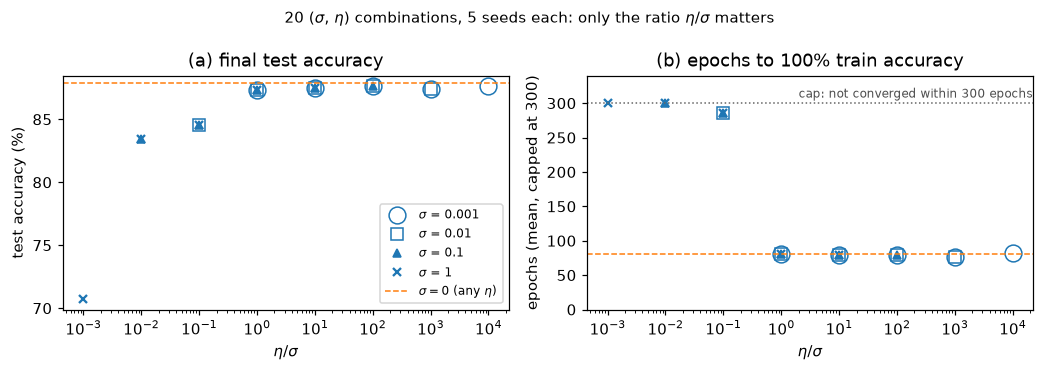

In [7]:
# Figure 2.2
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
styles = {0.001: dict(marker="o", ms=11, mfc="none"), 0.01: dict(marker="s", ms=7.5, mfc="none"),
          0.1: dict(marker="^", ms=5.5), 1: dict(marker="x", ms=5, mew=1.5)}
for s in SIGMAS:
    r = np.array([lr / s for lr in LRS])
    acc = np.array([100 * grid[s, lr][:, 1].mean() for lr in LRS])
    ep_conv = np.array([np.nan_to_num(grid[s, lr][:, 2], nan=GRID_EPOCHS).mean() for lr in LRS])
    axes[0].plot(r, acc, ls="none", color="C0", label=rf"$\sigma$ = {s:g}", **styles[s])
    axes[1].plot(r, ep_conv, ls="none", color="C0", **styles[s])

axes[0].axhline(100 * zero[:, 1].mean(), color="C1", ls="--", lw=1, label=r"$\sigma = 0$ (any $\eta$)")
axes[1].axhline(np.nanmean(zero[:, 2]), color="C1", ls="--", lw=1)
axes[1].axhline(GRID_EPOCHS, color="0.4", ls=":", lw=1)
axes[1].text(2, GRID_EPOCHS + 8, "cap: not converged within 300 epochs", fontsize=8, color="0.3")
axes[0].set(xscale="log", xlabel=r"$\eta / \sigma$", ylabel="test accuracy (%)", title="(a) final test accuracy")
axes[1].set(xscale="log", xlabel=r"$\eta / \sigma$", ylabel="epochs (mean, capped at 300)", ylim=(0, 340), title="(b) epochs to 100% train accuracy")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(r"20 ($\sigma$, $\eta$) combinations, 5 seeds each: only the ratio $\eta/\sigma$ matters", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_2_2_init_vs_lr.png")
plt.show()

Two small ratios trained for 1500 epochs.

In [8]:
# Longer Budget
for sigma, lr in [(1, 0.1), (1, 0.01)]:
    W, h, c = train_perceptron(X_train, y_train, lr=lr, init_std=sigma, rule="ovr", batch_size=32,
                               max_epochs=1500, seed=SEED, X_eval=X_test, y_eval=y_test)
    W0 = sigma * np.random.default_rng(SEED).standard_normal(W.shape)
    print(f"eta/sigma = {lr / sigma:g}: converged at epoch {c}, train {100 * h['train_acc'][-1]:.1f}%, "
          f"test {100 * h['test_acc'][-1]:.1f}%, |W0| = {np.linalg.norm(W0):.1f}, |W - W0| = {np.linalg.norm(W - W0):.1f}")

eta/sigma = 0.1: converged at epoch 348, train 100.0%, test 83.8%, |W0| = 51.0, |W - W0| = 30.9
eta/sigma = 0.01: converged at epoch None, train 99.7%, test 83.0%, |W0| = 51.0, |W - W0| = 29.1


Both rules with batch sizes 1 (online), 32 and 1707 (full batch), `DEFAULT` otherwise, 5 seeds each.

In [9]:
# Rule Comparison
print(f"{'rule':>10} {'batch':>6} {'converged':>10} {'epochs':>12} {'train %':>8} {'test %':>12}")
for rule in ["ovr", "multiclass"]:
    for bs in [1, 32, len(X_train)]:
        res = [train_perceptron(X_train, y_train, **{**DEFAULT, "rule": rule, "batch_size": bs}, seed=SEED + s,
                                X_eval=X_test, y_eval=y_test) for s in range(5)]
        c = np.array([np.nan if r[2] is None else r[2] for r in res])
        tr = np.array([r[1]["train_acc"][-1] for r in res]) * 100
        te = np.array([r[1]["test_acc"][-1] for r in res]) * 100
        ep_txt = f"{np.nanmean(c):.0f} ± {np.nanstd(c):.0f}" if (~np.isnan(c)).any() else "-"
        print(f"{rule:>10} {bs:>6} {f'{(~np.isnan(c)).sum()}/5':>10} {ep_txt:>12} {tr.mean():8.1f} {f'{te.mean():.1f} ± {te.std():.1f}':>12}")

      rule  batch  converged       epochs  train %       test %
       ovr      1        5/5       74 ± 9    100.0   87.8 ± 0.4
       ovr     32        5/5      79 ± 10    100.0   87.6 ± 0.7
       ovr   1707        0/5            -     98.6   87.9 ± 0.6
multiclass      1        5/5       36 ± 3    100.0   87.5 ± 0.6
multiclass     32        5/5       36 ± 3    100.0   87.9 ± 0.3
multiclass   1707        0/5            -     99.9   87.3 ± 0.2


## Accuracy Table and Confusion Matrix (seed=42 run)

Used for the report's accuracy comparison table and confusion-matrix error analysis, as opposed to the 10-seed average used earlier in this notebook.

In [ ]:
# !pip install --user seaborn


In [11]:
W, hist, converged_at = train_perceptron(
    X_train, y_train, **DEFAULT, seed=42, X_eval=X_test, y_eval=y_test
)

train_acc = accuracy(W, X_train, y_train)
test_acc = accuracy(W, X_test, y_test)
print(f"Converged at epoch: {converged_at}")
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")


Converged at epoch: 84
Train accuracy: 100.00%
Test accuracy: 86.50%


Accuracy comparison: perceptron vs. Task 1's nearest-mean and 1-NN classifiers.

In [12]:
# Accuracy comparison table: perceptron (seed=42) vs. Task 1's classifiers
print(f"{'Classifier':<22}{'Train Acc.':>12}{'Test Acc.':>12}")
print(f"{'Nearest-mean':<22}{86.35:>11.2f}%{80.40:>11.2f}%")
print(f"{'Perceptron (seed=42)':<22}{train_acc*100:>11.2f}%{test_acc*100:>11.2f}%")
print(f"{'1-NN':<22}{100.00:>11.2f}%{91.50:>11.2f}%")


Classifier              Train Acc.   Test Acc.
Nearest-mean                86.35%      80.40%
Perceptron (seed=42)       100.00%      86.50%
1-NN                       100.00%      91.50%


Confusion matrix for this seed=42 run, plus a check on digit 0's accuracy specifically.

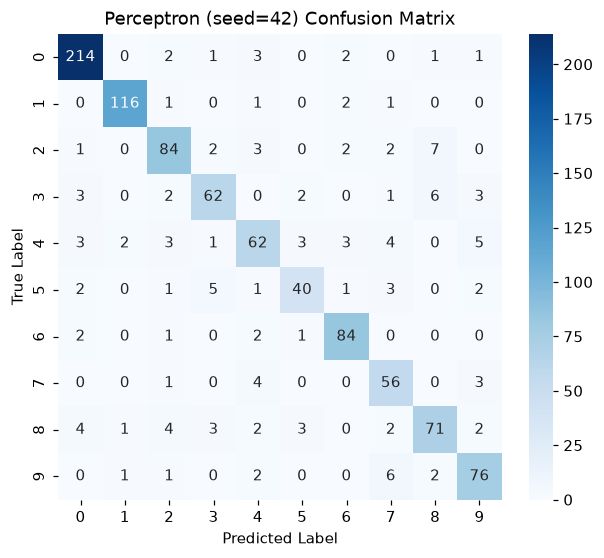

Digit 0 row (true=0): [214   0   2   1   3   0   2   0   1   1]
Digit 0 accuracy: 95.54%


In [13]:
import seaborn as sns

preds = predict(W, X_test)
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(y_test, preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
ax.set_title("Perceptron (seed=42) Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.savefig(FIG_DIR / "task2_perceptron_confusion_matrix.png")
plt.show()

print("Digit 0 row (true=0):", cm[0])
print(f"Digit 0 accuracy: {cm[0,0] / cm[0].sum() * 100:.2f}%")
